# Against other codes

Mag$\nu$s is not the only way to get an oscillation probability, and on the problems other
codes were built for it is not the fastest. This notebook measures that honestly, against
whichever of them are installed.

Two things make a comparison like this easy to get wrong, and both are handled explicitly
below. The first is **what problem is being solved**: a closed-form constant-density
expression and a general varying-profile integrator are not doing the same work, and timing
them on constant density flatters the former by construction. The second is **conventions**:
two codes given "the same" density can build different matter potentials, and the resulting
disagreement is not an accuracy difference even though it looks exactly like one.

Nothing here fails if a code is missing -- each is probed and skipped.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

In [2]:
import json
import pathlib
import sys
import time
import warnings

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.globaldefs as gd

warnings.simplefilter('ignore')

OSC = gd.load_nufit_params('NuFIT 6.1', 'NO')
L_KM, RHO, N_E = 1300.0, 2.848, 60
BASELINE = L_KM*gd.CONV_KM_TO_INV_EV
VCC = matter.vcc_func_from_rho_func(RHO, density_matter_is_in_g_per_cm3=True)
E_GEV = np.linspace(0.6, 20.0, N_E)
E = E_GEV*gd.UNIT_GEV
h_vac = np.asarray(hamiltonians.hamiltonian_3nu_vacuum_energy_independent(**OSC))

print('L = %.0f km, rho = %.3f g/cm^3, %d energies, 0.6-20 GeV' % (L_KM, RHO, N_E))
print('V_CC (Magnus) = %.6e eV' % VCC)

L = 1300 km, rho = 2.848 g/cm^3, 60 energies, 0.6-20 GeV
V_CC (Magnus) = 1.078065e-13 eV


## 1. Which codes are available

`nuSQuIDS` is a general neutrino transport solver; `NuOscProbExact` computes the exact
SU(3) closed form for piecewise-constant matter. Neither is a dependency of Mag$\nu$s, so both
are optional here.

In [3]:
AVAILABLE = {}

try:
    import nuSQuIDS as nsq
    AVAILABLE['nuSQuIDS'] = True
except Exception as exc:
    AVAILABLE['nuSQuIDS'] = False
    print('nuSQuIDS not available: %s' % exc)

# NuOscProbExact is not packaged on PyPI; point NUOSCPROBEXACT_SRC at its src/
# directory to include it.  Absent that, this notebook simply skips it.
import os
_npe_src = os.environ.get('NUOSCPROBEXACT_SRC')
if _npe_src and os.path.isdir(_npe_src):
    sys.path.insert(0, _npe_src)
try:
    import oscprob3nu
    import hamiltonians3nu
    AVAILABLE['NuOscProbExact'] = True
except Exception:
    AVAILABLE['NuOscProbExact'] = False

for name, ok in AVAILABLE.items():
    print('%-16s %s' % (name, 'available' if ok else 'not installed -- skipped'))

nuSQuIDS         available
NuOscProbExact   available


## 2. The reference

For a **constant** density the Hamiltonian is constant, so the evolution operator is a single
matrix exponential and `scipy.linalg.expm` is the exact answer. That makes an oracle that
belongs to none of the codes being compared.

In [4]:
reference = np.array([np.abs(expm(-1j*(h_vac/e + np.diag([VCC, 0.0, 0.0]))*BASELINE))[0, 1]**2
                      for e in E])
print('reference P(nu_mu -> nu_e): %.6f ... %.6f' % (reference[0], reference[-1]))


def best_of(call, repeats=3):
    fastest, result = np.inf, None
    for _ in range(repeats):
        t0 = time.perf_counter()
        result = call()
        fastest = min(fastest, time.perf_counter() - t0)
    return result, fastest

reference P(nu_mu -> nu_e): 0.013699 ... 0.001491


## 3. Constant density: speed

This is the problem `NuOscProbExact` exists for -- an exact closed form, evaluated once per
energy. Mag$\nu$s solves the general problem and pays for the generality. Expect to lose.

In [5]:
results = []

P_magnus, t_magnus = best_of(lambda: np.asarray(oscprob.osc_prob_3nu_matter_constant_density(
    E, BASELINE, RHO, **OSC, density_matter_is_in_g_per_cm3=True,
    nu_i=gd.NUMU, nu_f=gd.NUE)))
results.append(('Magnus (batched wrapper)', P_magnus, t_magnus))

if AVAILABLE['NuOscProbExact']:
    h_npe = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(**OSC)
    P_npe, t_npe = best_of(lambda: np.array([
        oscprob3nu.probabilities_3nu(
            hamiltonians3nu.hamiltonian_3nu_matter(h_npe, e, VCC), BASELINE)[3]
        for e in E]))
    results.append(('NuOscProbExact', P_npe, t_npe))

print('%-28s %-11s %-11s %s' % ('code', 'time [s]', 'us/point', 'max |P - exact|'))
print('-'*66)
for name, P, t in results:
    print('%-28s %-11.4f %-11.1f %.3e'
          % (name, t, 1.0e6*t/N_E, np.max(np.abs(P - reference))))

code                         time [s]    us/point    max |P - exact|
------------------------------------------------------------------
Magnus (batched wrapper)     0.0093      155.3       1.180e-16
NuOscProbExact               0.0010      17.1        4.892e-16


Both are exact to round-off; the closed form is several times faster. That is the
right result and it is worth stating plainly: **if constant density is your whole problem, a
closed-form code is the better tool.** Mag$\nu$s earns its cost on profiles that vary, where no
closed form exists -- notebook 16 measures a mean-density substitution being wrong by 0.51 on
an Earth chord.

## 4. A conventions trap, and why the next table is in vacuum

Running nuSQuIDS on the same nominal problem produces a disagreement of a few times
$10^{-4}$ that **does not improve when its solver tolerance is tightened**. A plateau like
that is the signature of a systematic offset rather than a convergence limit.

In [6]:
def run_nusquids(rho, tolerance):
    """P(nu_mu -> nu_e) from nuSQuIDS on the same configuration."""
    units = nsq.Const()
    solver = nsq.nuSQUIDS(E_GEV*units.GeV, 3, nsq.NeutrinoType.neutrino, False)
    if rho == 0.0:
        solver.Set_Body(nsq.Vacuum())
        solver.Set_Track(nsq.Vacuum.Track(L_KM*units.km))
    else:
        solver.Set_Body(nsq.ConstantDensity(rho, 0.5))
        solver.Set_Track(nsq.ConstantDensity.Track(L_KM*units.km))
    solver.Set_MixingAngle(0, 1, np.arcsin(OSC['s12']))
    solver.Set_MixingAngle(0, 2, np.arcsin(OSC['s13']))
    solver.Set_MixingAngle(1, 2, np.arcsin(OSC['s23']))
    solver.Set_CPPhase(0, 2, OSC['dCP'])
    solver.Set_SquareMassDifference(1, OSC['D21'])
    solver.Set_SquareMassDifference(2, OSC['D31'])
    solver.Set_rel_error(tolerance)
    solver.Set_abs_error(tolerance)
    state = np.zeros((N_E, 3))
    state[:, 1] = 1.0                                  # start as nu_mu
    solver.Set_initial_state(state, nsq.Basis.flavor)
    solver.EvolveState()
    return np.array([solver.EvalFlavorAtNode(0, i) for i in range(N_E)])


if AVAILABLE['nuSQuIDS']:
    print('%-18s %s' % ('solver tolerance', 'max |P - exact|, in matter'))
    for tolerance in (1.0e-5, 1.0e-7, 1.0e-10):
        P, _ = best_of(lambda t=tolerance: run_nusquids(RHO, t), repeats=1)
        print('%-18.0e %.3e' % (tolerance, np.max(np.abs(P - reference))))

solver tolerance   max |P - exact|, in matter
1e-05              2.804e-04
1e-07              2.808e-04
1e-10              2.808e-04


The diagnosis: run the same code in **vacuum**, where there is no matter potential to
disagree about. If the solver is fine, the vacuum comparison will be tight -- and it is, by
about four orders of magnitude.

In [7]:
if AVAILABLE['nuSQuIDS']:
    vacuum_reference = np.array([np.abs(expm(-1j*(h_vac/e)*BASELINE))[0, 1]**2 for e in E])
    P_vac, _ = best_of(lambda: run_nusquids(0.0, 1.0e-12), repeats=1)
    print('vacuum : max |nuSQuIDS - exact| = %.3e' % np.max(np.abs(P_vac - vacuum_reference)))

    # What potential would reconcile them?  Rebuild the exact answer with V_CC
    # scaled, and find the scale that matches.
    P_matter, _ = best_of(lambda: run_nusquids(RHO, 1.0e-12), repeats=1)
    scales = np.linspace(0.95, 1.05, 21)
    gaps = []
    for scale in scales:
        ref_scaled = np.array([
            np.abs(expm(-1j*(h_vac/e + np.diag([VCC*scale, 0.0, 0.0]))*BASELINE))[0, 1]**2
            for e in E])
        gaps.append(np.max(np.abs(P_matter - ref_scaled)))
    best = int(np.argmin(gaps))
    unity = int(np.argmin(np.abs(scales - 1.0)))
    print('matter : best agreement at V_CC scale %.3f (residual %.2e)'
          % (scales[best], gaps[best]))
    print('         at Magnus\'s own V_CC   (scale %.3f), residual %.2e'
          % (scales[unity], gaps[unity]))

vacuum : max |nuSQuIDS - exact| = 3.967e-08
matter : best agreement at V_CC scale 1.010 (residual 6.34e-05)
         at Magnus's own V_CC   (scale 1.000), residual 2.81e-04


In vacuum nuSQuIDS reproduces the exact answer to $\sim10^{-8}$ -- its solver is doing
its job. In matter, the disagreement is minimised at a matter potential about **1% larger**
than the one Mag$\nu$s builds from the same nominal $\rho$ and $Y_e$. That is a difference in
how the electron number density is derived from a mass density -- the average nucleon mass and
the electron fraction convention -- and **not** an accuracy difference in either code.

This is why the accuracy column in section 3 is only quoted for codes sharing Mag$\nu$s's
potential, and why the honest cross-code accuracy statement is the vacuum one. Fixing it
properly means agreeing a conversion, not tightening a tolerance.

## 5. Speed against accuracy, across six codes

The comparison above is two codes at a single working point. The useful picture is the whole
trade-off: every code has a dial -- a solver tolerance, a number of Newton steps, a batch mode
-- and what matters is the accuracy it buys per microsecond.

The NuOscProbExact project measured five external codes this way and published the result;
`notebooks/external_speed_accuracy.json` is that measurement, redistributed with attribution.
The configuration is the one used above -- $L = 1300$ km, $\rho = 3$ g cm$^{-3}$, three
flavours, $P(\nu_\mu \to \nu_e)$, 60 energies from 0.6 to 20 GeV -- scored against a 50-digit
`mpmath` matrix exponential.

**A warning about the timings, which is worth more than the figure.** Those numbers were taken
on other hardware, and there is no single factor that maps them onto this machine. Running
NuOscProbExact here in both of its modes gives *two different* conversion factors.

In [8]:
EXTERNAL = json.loads((pathlib.Path.cwd()/'external_speed_accuracy.json').read_text())
print(EXTERNAL['_attribution'])
print()

frozen = {p['label']: p['us_per_probability']
          for s in EXTERNAL['series'] if s['name'] == 'NuOscProbExact'
          for p in s['points']}

if AVAILABLE['NuOscProbExact']:
    h_npe2 = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(**OSC)
    _, t_loop = best_of(lambda: np.array([
        oscprob3nu.probabilities_3nu(
            hamiltonians3nu.hamiltonian_3nu_matter(h_npe2, e, VCC), BASELINE)[3]
        for e in E]))
    stacked = hamiltonians3nu.hamiltonian_3nu_matter(h_npe2, E, VCC)
    _, t_arr = best_of(lambda: oscprob3nu.probabilities_3nu(stacked, BASELINE))

    print('%-16s %12s %12s %9s' % ('NuOscProbExact', 'frozen [us]', 'here [us]', 'factor'))
    print('-'*52)
    for label, here in (('One at a time', 1.0e6*t_loop/N_E), ('Array', 1.0e6*t_arr/N_E)):
        print('%-16s %12.3f %12.3f %9.2f'
              % (label, frozen[label], here, frozen[label]/here))

Speed and accuracy of five external codes, measured by the NuOscProbExact project on its own hardware.  Redistributed here with attribution; see github.com/mbustama/NuOscProbExact.

NuOscProbExact    frozen [us]    here [us]    factor
----------------------------------------------------
One at a time          31.235       12.802      2.44
Array                   0.955        1.038      0.92


One workload says this machine is more than twice as fast; the other says it is
slightly slower. That is not measurement noise -- looping is bound by the Python interpreter
and the array path is bound by BLAS, and two machines need not rank the same way in both.
**A single "machine factor" does not exist.** So nothing below is rescaled, and Mag$\nu$s is
plotted with a distinct symbol as a reminder that its horizontal position is not commensurate
with the others'.

Accuracy, by contrast, is a property of the algorithm rather than the hardware, and transfers
without qualification. It is the axis to read.

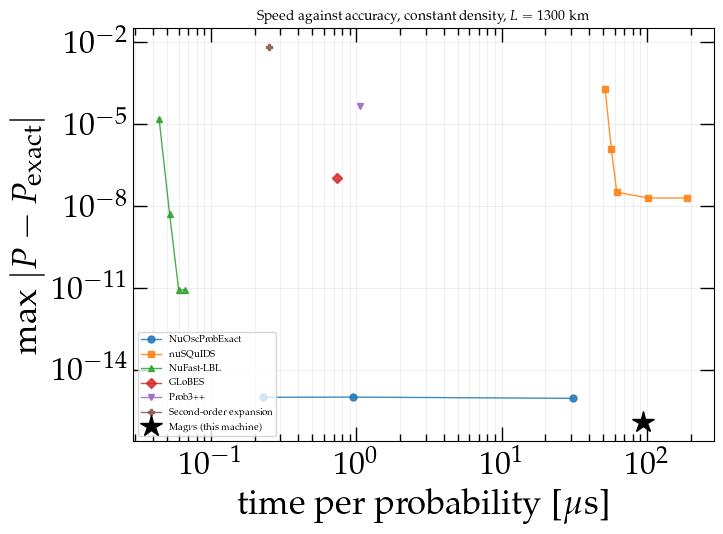

In [9]:
fig, ax = plt.subplots(figsize=(7.4, 5.0))

FLOOR = 1.0e-16          # machine precision; several codes sit on it
markers = {'NuOscProbExact': 'o', 'nuSQuIDS': 's', 'NuFast-LBL': '^',
           'GLoBES': 'D', 'Prob3++': 'v', 'Second-order expansion': 'P'}
for i, series in enumerate(EXTERNAL['series']):
    us = [p['us_per_probability'] for p in series['points']]
    err = [max(p['max_abs_error'], FLOOR) for p in series['points']]
    ax.plot(us, err, marker=markers.get(series['name'], 'o'), ms=5,
            color='C%d' % i, lw=1.0, alpha=0.85, label=series['name'])

P_m, t_m = best_of(lambda: np.asarray(oscprob.osc_prob_3nu_matter_constant_density(
    E, BASELINE, RHO, **OSC, density_matter_is_in_g_per_cm3=True,
    nu_i=gd.NUMU, nu_f=gd.NUE)))
ax.plot([1.0e6*t_m/N_E], [max(float(np.max(np.abs(P_m - reference))), FLOOR)],
        marker='*', ms=16, color='k', ls='none', label=r'Mag$\nu$s (this machine)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'time per probability [$\mu$s]')
ax.set_ylabel(r'max $|P - P_{\rm exact}|$')
ax.set_title(r'Speed against accuracy, constant density, $L = 1300$ km', fontsize=10)
ax.grid(True, which='both', alpha=0.2)
ax.legend(fontsize=7, loc='lower left')

Read the vertical axis first. Three codes reach machine precision -- Mag$\nu$s,
NuOscProbExact, and NuFast at three Newton steps -- and the rest trade accuracy for speed by
between four and thirteen orders of magnitude. The second-order expansion is the extreme:
$6\times10^{-3}$, which is the size of the effects notebooks 15 and 17 are about, for a
quarter of a microsecond.

Read the horizontal axis only *within* a curve. nuSQuIDS tightening its tolerance from
$10^{-4}$ to $10^{-8}$ costs 20% and buys four orders of magnitude; past that it costs three
times as much and buys nothing, having hit its own floor. That statement is about nuSQuIDS
alone and survives a change of machine. "Code A is faster than code B" does not.

## Summary

| | |
|---|---|
| constant density, exactness | Mag$\nu$s and NuOscProbExact both $\sim10^{-16}$ |
| constant density, speed | the closed form wins, several-fold |
| vacuum, nuSQuIDS vs exact | $\sim10^{-8}$ -- solver is fine |
| matter, nuSQuIDS vs Mag$\nu$s | a **1% $V_{\rm CC}$ convention difference**, not accuracy |

The comparison worth making is not "which code is fastest" but "which code solves my problem".
For constant density, reach for a closed form. For an arbitrary varying profile, a custom
Hamiltonian, or a BSM term that no closed form covers, that option does not exist -- which is
where Mag$\nu$s's cost buys something.

And before comparing any two codes' numbers: **check that they agree in vacuum first.** If they
do not, the disagreement is in the solvers. If they do and they disagree in matter, it is in
the conventions, and no amount of tolerance will close it.

---

**Previous:** [Performance](24_magnus_performance.ipynb)  
**Next:** [Fourteen years of NuFIT](26_magnus_nufit_evolution.ipynb) --- how the parameter likelihood, not just the best fit, moves the probability  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)